# 05 – Car Parts Segmentation Baseline Fine-Tuning

## Purpose

This notebook fine-tunes and evaluates a pretrained YOLO11n segmentation baseline on the cleaned, leakage-safe car-parts dataset.

## 1. Setup

### 1.1 Install the Required Ultralytics Version

In [ ]:
import sys

!{sys.executable} -m pip install ultralytics==8.4.138

### 1.2 Import Libraries

In [ ]:
from pathlib import Path
from zipfile import ZipFile
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from matplotlib.patches import Polygon
from PIL import Image
from ultralytics import YOLO
from ultralytics import __version__ as ultralytics_version

### 1.3 Confirm the Colab GPU Environment

In [3]:
CUDA_AVAILABLE = torch.cuda.is_available()

if CUDA_AVAILABLE:
    DEVICE_NAME = torch.cuda.get_device_name(0)
else:
    DEVICE_NAME = "CPU"

print("Ultralytics version:", ultralytics_version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", CUDA_AVAILABLE)
print("Selected device:", DEVICE_NAME)

Ultralytics version: 8.4.138
PyTorch version: 2.11.0+cu128
CUDA available: True
Selected device: Tesla T4


## 2. Configuration and Paths

### 2.1 Mount Google Drive

In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive

### 2.2 Define Dataset and Output Paths

In [ ]:
DATA_ZIP_PATH = Path(
    "/content/drive/MyDrive/data/carparts-seg-processed.zip"
)
EXTRACT_DIR = Path("/content/data")
PROCESSED_ROOT = EXTRACT_DIR / "carparts-seg-processed"
DATA_CONFIG_PATH = PROCESSED_ROOT / "carparts-seg-processed.yaml"

RUNS_DIRECTORY = Path(
    "/content/drive/MyDrive/qaddir-training-results"
)
RUN_NAME = "carparts_yolo11n_baseline"

print("Dataset archive:", DATA_ZIP_PATH)
print("Local dataset directory:", PROCESSED_ROOT)
print("Training output directory:", RUNS_DIRECTORY / RUN_NAME)

In [5]:
if not DATA_ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Dataset ZIP was not found: {DATA_ZIP_PATH}"
    )

archive_size_mb = DATA_ZIP_PATH.stat().st_size / 1024**2
print("Dataset ZIP found successfully.")
print("Size:", round(archive_size_mb, 2), "MB")

Dataset ZIP found successfully.
Size: 129.49 MB


## 3. Data Loading

### 3.1 Extract the Dataset to Colab

In [6]:
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with ZipFile(DATA_ZIP_PATH, "r") as zip_file:
    zip_file.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")
print("Extraction directory:", EXTRACT_DIR)

Dataset extracted successfully.
Extraction directory: /content/data


### 3.2 Locate the Dataset YAML

In [7]:
yaml_files = list(EXTRACT_DIR.rglob("*.yaml"))

print("YAML files found:")

for yaml_path in yaml_files:
    print(yaml_path)

YAML files found:
/content/data/carparts-seg-processed/carparts-seg-processed.yaml


### 3.3 Load and Update the Local YAML Copy

In [8]:
with DATA_CONFIG_PATH.open("r", encoding="utf-8") as yaml_file:
    dataset_config = yaml.safe_load(yaml_file)

print("Dataset configuration loaded successfully.")
print("Dataset path:", DATA_CONFIG_PATH)
print("\nConfiguration:")
print(dataset_config)

Dataset configuration loaded successfully.
Dataset path: /content/data/carparts-seg-processed/carparts-seg-processed.yaml

Configuration:
{'path': 'C:/Users/Hai-1/Desktop/qaddir-vehicle-damage-assessment/data/carparts-seg-processed', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_light', 4: 'front_bumper', 5: 'front_door', 6: 'front_glass', 7: 'front_light', 8: 'hood', 9: 'side_mirror', 10: 'tailgate', 11: 'trunk', 12: 'wheel'}}


In [9]:
dataset_config["path"] = str(PROCESSED_ROOT)

with DATA_CONFIG_PATH.open("w", encoding="utf-8") as yaml_file:
    yaml.safe_dump(
        dataset_config,
        yaml_file,
        sort_keys=False,
        allow_unicode=True
    )

print("Dataset path updated for Google Colab.")
print("New dataset root:", dataset_config["path"])

Dataset path updated for Google Colab.
New dataset root: /content/data/carparts-seg-processed


## 4. Data Validation

### 4.1 Check the Extracted Dataset Structure

In [10]:
print("Train images:", PROCESSED_ROOT / "images/train")
print("Validation images:", PROCESSED_ROOT / "images/val")
print("Test images:", PROCESSED_ROOT / "images/test")

print("\nFolders exist:")
print("Train:", (PROCESSED_ROOT / "images/train").exists())
print("Validation:", (PROCESSED_ROOT / "images/val").exists())
print("Test:", (PROCESSED_ROOT / "images/test").exists())

Train images: /content/data/carparts-seg-processed/images/train
Validation images: /content/data/carparts-seg-processed/images/val
Test images: /content/data/carparts-seg-processed/images/test

Folders exist:
Train: True
Validation: True
Test: True


### 4.2 Validate the 13 Merged Classes

In [ ]:
expected_class_names = [
    "back_bumper",
    "back_door",
    "back_glass",
    "back_light",
    "front_bumper",
    "front_door",
    "front_glass",
    "front_light",
    "hood",
    "side_mirror",
    "tailgate",
    "trunk",
    "wheel"
]

configured_names = dataset_config["names"]

if isinstance(configured_names, dict):
    configured_names = [
        configured_names[key]
        for key in sorted(configured_names, key=int)
    ]

if configured_names != expected_class_names:
    raise ValueError(
        "The dataset YAML does not contain the expected 13 merged classes."
    )

class_names = configured_names
print("Class validation passed: 13 merged car-part classes.")

### 4.3 Validate Image and Label Pairs

In [11]:
dataset_records = []

for split in ["train", "val", "test"]:
    image_dir = PROCESSED_ROOT / "images" / split
    label_dir = PROCESSED_ROOT / "labels" / split

    image_files = list(image_dir.glob("*.jpg"))
    label_files = list(label_dir.glob("*.txt"))

    image_names = {image.stem for image in image_files}
    label_names = {label.stem for label in label_files}

    missing_labels = image_names - label_names
    orphan_labels = label_names - image_names

    empty_labels = [
        label.name
        for label in label_files
        if not label.read_text(encoding="utf-8").strip()
    ]

    dataset_records.append({
        "Split": split,
        "Images": len(image_files),
        "Labels": len(label_files),
        "Missing Labels": len(missing_labels),
        "Orphan Labels": len(orphan_labels),
        "Empty Labels": len(empty_labels)
    })

dataset_validation_df = pd.DataFrame(dataset_records)
dataset_validation_df

,Split,Images,Labels,Missing Labels,Orphan Labels,Empty Labels
0,train,2571,2571,0,0,0
1,val,561,561,0,0,0
2,test,554,554,0,0,0


### 4.4 Validate Segmentation Labels

In [12]:
number_of_classes = len(dataset_config["names"])
label_validation_records = []

for split in ["train", "val", "test"]:
    label_dir = PROCESSED_ROOT / "labels" / split

    polygon_count = 0
    invalid_class_ids = 0
    invalid_polygon_structures = 0
    out_of_range_coordinates = 0
    unreadable_lines = 0

    for label_path in label_dir.glob("*.txt"):
        lines = label_path.read_text(encoding="utf-8").splitlines()

        for line in lines:
            values = line.strip().split()

            try:
                numbers = [float(value) for value in values]
            except ValueError:
                unreadable_lines += 1
                continue

            if not numbers:
                continue

            class_value = numbers[0]
            coordinates = numbers[1:]

            if not class_value.is_integer():
                invalid_class_ids += 1
                continue

            class_id = int(class_value)

            if class_id < 0 or class_id >= number_of_classes:
                invalid_class_ids += 1

            if len(coordinates) < 6 or len(coordinates) % 2 != 0:
                invalid_polygon_structures += 1
                continue

            if any(coordinate < 0 or coordinate > 1 for coordinate in coordinates):
                out_of_range_coordinates += 1

            polygon_count += 1

    label_validation_records.append({
        "Split": split,
        "Polygons": polygon_count,
        "Invalid Class IDs": invalid_class_ids,
        "Invalid Polygon Structures": invalid_polygon_structures,
        "Out-of-Range Coordinates": out_of_range_coordinates,
        "Unreadable Lines": unreadable_lines
    })

label_validation_df = pd.DataFrame(label_validation_records)
label_validation_df

,Split,Polygons,Invalid Class IDs,Invalid Polygon Structures,Out-of-Range Coordinates,Unreadable Lines
0,train,14299,0,0,0,0
1,val,3096,0,0,0,0
2,test,2967,0,0,0,0


## 5. Analysis and Visualization

### 5.1 Dataset Composition

The processed dataset contains existing augmented image files. Every version of an independent source image remains in exactly one split.

| Split | Independent source images | Existing image files | Modeling role |
|---|---:|---:|---|
| Train | 409 | 2,571 | Updates model weights |
| Validation | 88 | 561 | Monitoring, early stopping, checkpoint selection, and validation evaluation |
| Test | 88 | 554 | Untouched final evaluation set |
| **Total** | **585** | **3,686** | |

### 5.2 Display a Training Annotation Sample

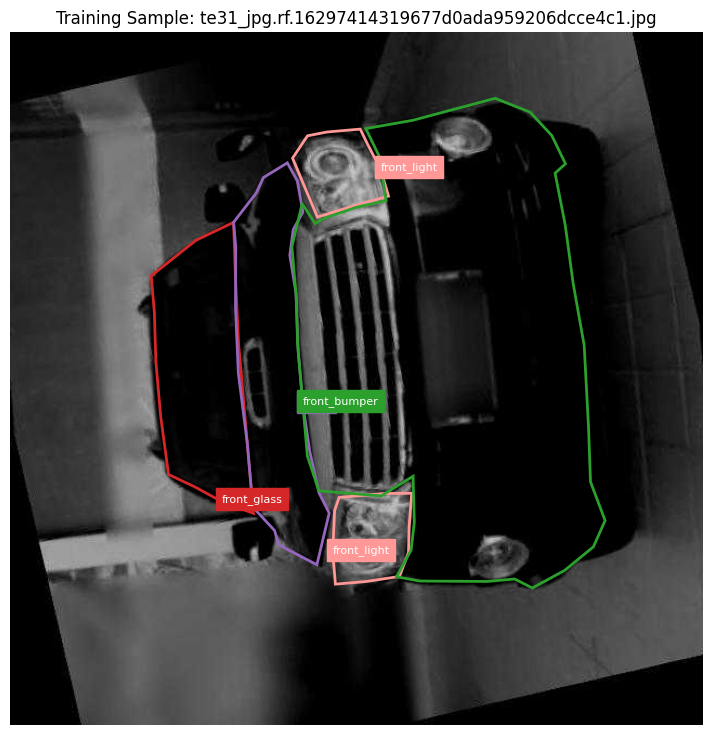

In [13]:
class_names = dataset_config["names"]

if isinstance(class_names, dict):
    class_names = [
        class_names[key]
        for key in sorted(class_names, key=lambda value: int(value))
    ]

train_image_dir = PROCESSED_ROOT / "images" / "train"
train_label_dir = PROCESSED_ROOT / "labels" / "train"

train_images = sorted(train_image_dir.glob("*.jpg"))
sample_image_path = random.Random(42).choice(train_images)
sample_label_path = train_label_dir / f"{sample_image_path.stem}.txt"

image = Image.open(sample_image_path).convert("RGB")
image_width, image_height = image.size

figure, axis = plt.subplots(figsize=(9, 9))
axis.imshow(image)

label_lines = sample_label_path.read_text(
    encoding="utf-8"
).splitlines()

for line in label_lines:
    values = [float(value) for value in line.split()]

    class_id = int(values[0])
    coordinates = values[1:]

    polygon_points = []

    for index in range(0, len(coordinates), 2):
        x = coordinates[index] * image_width
        y = coordinates[index + 1] * image_height
        polygon_points.append((x, y))

    color = plt.cm.tab20(class_id % 20)

    polygon = Polygon(
        polygon_points,
        closed=True,
        fill=False,
        edgecolor=color,
        linewidth=2
    )

    axis.add_patch(polygon)

    first_x, first_y = polygon_points[0]

    axis.text(
        first_x,
        first_y,
        class_names[class_id],
        color="white",
        fontsize=8,
        backgroundcolor=color
    )

axis.set_title(f"Training Sample: {sample_image_path.name}")
axis.axis("off")
plt.show()

## 6. Processing

### 6.1 Define the Baseline Training Configuration

In [14]:
SEED = 42
MODEL_WEIGHTS = "yolo11n-seg.pt"

IMAGE_SIZE = 640
EPOCHS = 50
PATIENCE = 10
BATCH_SIZE = 8
WORKERS = 2
DEVICE = 0

RUNS_DIRECTORY.mkdir(parents=True, exist_ok=True)

BASELINE_TRAINING_CONFIG = {
    "data": str(DATA_CONFIG_PATH),
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "imgsz": IMAGE_SIZE,
    "batch": BATCH_SIZE,
    "device": DEVICE,
    "workers": WORKERS,
    "seed": SEED,
    "deterministic": True,
    "pretrained": True,
    "project": str(RUNS_DIRECTORY),
    "name": RUN_NAME,
    "exist_ok": True,
    "save": True,
    "plots": True
}

print("Model:", MODEL_WEIGHTS)
print("Image size:", IMAGE_SIZE)
print("Epochs:", EPOCHS)
print("Patience:", PATIENCE)
print("Batch size:", BATCH_SIZE)
print("Device: GPU", DEVICE)
print("Results directory:", RUNS_DIRECTORY)
print("Run name:", RUN_NAME)

Model: yolo11n-seg.pt
Image size: 640
Epochs: 50
Patience: 10
Batch size: 8
Device: GPU 0
Results directory: /content/drive/MyDrive/qaddir-training-results
Run name: carparts_yolo11n_baseline


### 6.2 Disable Additional Training-Time Augmentation

In [ ]:
BASELINE_AUGMENTATION_CONFIG = {
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.0,
    "degrees": 0.0,
    "translate": 0.0,
    "scale": 0.0,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.0,
    "bgr": 0.0,
    "mosaic": 0.0,
    "mixup": 0.0,
    "cutmix": 0.0,
    "copy_paste": 0.0,
    "erasing": 0.0,
    "auto_augment": None
}

pd.Series(
    BASELINE_AUGMENTATION_CONFIG,
    name="Baseline Value"
).to_frame()

### 6.3 Set the Random Seed

In [15]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


### 6.4 Load the Pretrained YOLO11n Segmentation Model

In [16]:
model = YOLO(MODEL_WEIGHTS)
print("Pretrained YOLO11n segmentation model loaded successfully.")
model.info()

Pretrained YOLO11n segmentation model loaded successfully.
YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients, 10.0 GFLOPs


(203, 2876848, 0, 9.9593344)

### 6.5 Fine-Tune the Baseline

Ultralytics reads the `train` and `val` paths from the YAML. Only the training split updates model weights; validation is used for monitoring, early stopping, and selecting `best.pt`.

In [17]:
baseline_results = model.train(
    **BASELINE_TRAINING_CONFIG,
    **BASELINE_AUGMENTATION_CONFIG
)

Ultralytics 8.4.138 · Python 3.13.15 · PyTorch 2.11.0+cu128 · Tesla T4
Training data: 2,571 existing image files from 409 independent sources
Validation data: 561 existing image files from 88 independent sources
Additional training-time augmentation: disabled
EarlyStopping: Training stopped after epoch 31 because validation performance did not improve for 10 epochs.
Best results were observed at epoch 21, and the best model was saved as best.pt.
Results saved to /content/drive/MyDrive/qaddir-training-results/carparts_yolo11n_baseline

**Recorded training result:**

Ultralytics stopped after epoch 31. The best validation result occurred at epoch 21, and that checkpoint was saved as `best.pt`.

## 7. Results

### 7.1 Locate the Best Checkpoint

In [18]:
BEST_MODEL_PATH = (
    RUNS_DIRECTORY
    / RUN_NAME
    / "weights"
    / "best.pt"
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model checkpoint was not found: {BEST_MODEL_PATH}"
    )

print("Best model found:")
print(BEST_MODEL_PATH)

Best model found:
/content/drive/MyDrive/qaddir-training-results/carparts_yolo11n_baseline/weights/best.pt

### 7.2 Evaluate the Best Checkpoint on Validation

This evaluation uses `split="val"` only. The test split remains untouched.

In [18]:
best_model = YOLO(str(BEST_MODEL_PATH))

validation_results = best_model.val(
    data=str(DATA_CONFIG_PATH),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
    project=str(RUNS_DIRECTORY),
    name=f"{RUN_NAME}_validation",
    exist_ok=True
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,837,103 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1000.7±300.1 MB/s, size: 36.9 KB)
val: Scanning /content/data/carparts-seg-processed/labels/val.cache... 561 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 561/561 168.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 5.7it/s 12.4s
                   all        561       3096      0.812      0.821      0.848      0.665      0.815      0.822      0.848      0.633
           back_bumper        132        132      0.908      0.879      0.947      0.718      0.886      0.856      0.911      0.637
             back_door        245        245      0.743      0.869      0.857      0.731      0.737      0.861      0.844      0.687
            back_glass 

### 7.3 Recorded Validation Metrics

| Result | Mask mAP50 | Mask mAP50–95 |
|---|---:|---:|
| Overall validation | 0.848 | 0.633 |
| `side_mirror` | 0.789 | 0.472 |
| `trunk` | 0.751 | 0.528 |
| `wheel` | 0.526 | 0.252 |

- Best epoch: **21**
- Training stopped at epoch: **31**

### 7.4 Saved Artifacts

Training checkpoints, curves, plots, and validation outputs are stored in Google Drive under:

`/content/drive/MyDrive/qaddir-training-results/carparts_yolo11n_baseline`

## 8. Decisions and Next Steps

### 8.1 Baseline Decisions

- Fine-tuning started from pretrained `yolo11n-seg.pt` weights.
- Only the 2,571 training files updated model weights.
- The 561 validation files were used for monitoring, early stopping, checkpoint selection, and validation evaluation.
- The 554 test files remain untouched for final evaluation.
- Validation and test image files remain unchanged.
- Additional Ultralytics training-time augmentation was disabled because the processed dataset already contains augmented versions.

### 8.2 Next Step

Review this baseline together with the external-data audit before defining a separate augmentation experiment. No augmented model is trained in this notebook.